# Predicting Diabetes

A binary classification project that predicts whether a patient is likely to have diabetes, using the Pima Indians Diabetes dataset.

## Overview

Diabetes is a chronic condition where the body can't produce or use insulin properly, leading to high blood sugar. Catching it early makes a big difference in how it's managed.

This project trains and compares four classifiers — **Logistic Regression**, **Decision Tree**, **Random Forest**, and **Naive Bayes** — to predict whether a patient has diabetes from 8 health measurements, then tunes the best-performing model and saves it so it can be used outside the notebook (see the Streamlit app in this repo).

## Dataset

Source: [Pima Indians Diabetes Dataset on Kaggle](https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset), originally from the National Institute of Diabetes and Digestive and Kidney Diseases.

Download `diabetes.csv` from the link above and place it in the same folder as this notebook.

**Features:**
- `Pregnancies` — number of pregnancies
- `Glucose` — plasma glucose concentration (mg/dL)
- `BloodPressure` — diastolic blood pressure (mm Hg)
- `SkinThickness` — triceps skin fold thickness (mm)
- `Insulin` — 2-hour serum insulin (mu U/ml)
- `BMI` — body mass index
- `DiabetesPedigreeFunction` — a score estimating diabetes likelihood based on family history
- `Age` — age in years
- `Outcome` — target label, 1 = diabetic, 0 = not diabetic

In [2]:
import numpy as np
import pandas as pd
from time import time
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

data = pd.read_csv("diabetes.csv")
display(data.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Cleaning: zeros that are actually missing values

In this dataset, several columns use `0` as a stand-in for "not recorded" rather than a real measurement — nobody has a blood pressure or BMI of zero. Left as-is, these zeros would drag down the mean and distort the model, so we replace them with the column mean.

We check `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` — any of these being exactly 0 is a missing value, not a real reading.

In [3]:
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    print(f"Zeros in {col}: {(data[col] == 0).sum()}")

Zeros in Glucose: 5
Zeros in BloodPressure: 35
Zeros in SkinThickness: 227
Zeros in Insulin: 374
Zeros in BMI: 11


In [4]:
# Replace 0s with the column mean for each affected feature.
# Cast to float first -- pandas won't let us assign a mean (float) into
# a column that's still stored as int.
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    data[col] = data[col].astype(float)
    data.loc[data[col] == 0, col] = data[col].mean()

# Confirm no zeros remain
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    print(f"Zeros left in {col}: {(data[col] == 0).sum()}")

Zeros left in Glucose: 0
Zeros left in BloodPressure: 0
Zeros left in SkinThickness: 0
Zeros left in Insulin: 0
Zeros left in BMI: 0


In [5]:
display(data.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.000000,79.799479,33.6,0.627,50,1
1,1,85.0,66.0,29.000000,79.799479,26.6,0.351,31,0
2,8,183.0,64.0,20.536458,79.799479,23.3,0.672,32,1
3,1,89.0,66.0,23.000000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.000000,168.000000,43.1,2.288,33,1


## Class balance

Before modeling, it's worth checking how imbalanced the target is -- this affects which metric (accuracy vs. F-score) actually tells us something useful.

In [6]:
n_records = len(data.index)
n_diabetic = data[data.Outcome == 1].shape[0]
n_not_diabetic = data[data.Outcome == 0].shape[0]
diabetic_pct = (n_diabetic / n_records) * 100

print(f"Total records: {n_records}")
print(f"Diagnosed with diabetes: {n_diabetic}")
print(f"Not diagnosed: {n_not_diabetic}")
print(f"Diabetic %: {diabetic_pct:.2f}%")

Total records: 768
Diagnosed with diabetes: 268
Not diagnosed: 500
Diabetic %: 34.90%


About a third of patients in the dataset are diabetic. That's imbalanced enough that accuracy alone can be misleading — a model that just predicts "not diabetic" every time would still be right roughly 65% of the time. That's why we also track the F-score (using beta=0.5, which weighs precision a bit more than recall) throughout this notebook.

## Preparing the features

Two columns, `SkinThickness` and `Insulin`, are right-skewed (most values are small/medium, with a long tail of higher values). Skewed features can pull linear models like Logistic Regression off balance, so we log-transform them to make their distribution more symmetric.

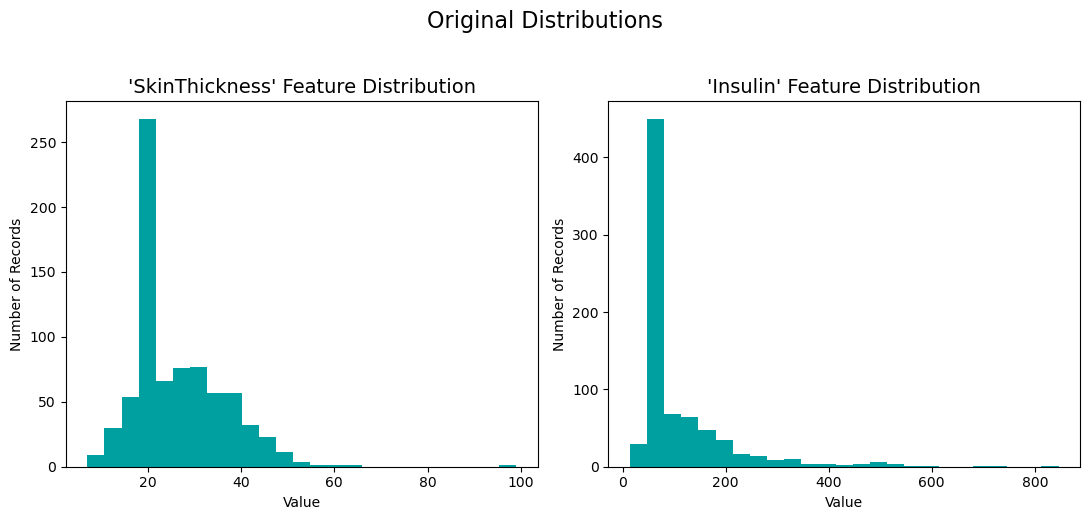

In [7]:
target = data["Outcome"]
features = data.drop("Outcome", axis=1)

def plot_distribution(df, title):
    fig = plt.figure(figsize=(11, 5))
    for i, feature in enumerate(["SkinThickness", "Insulin"]):
        ax = fig.add_subplot(1, 2, i + 1)
        ax.hist(df[feature], bins=25, color="#00A0A0")
        ax.set_title(f"'{feature}' Feature Distribution", fontsize=14)
        ax.set_xlabel("Value")
        ax.set_ylabel("Number of Records")
    fig.suptitle(title, fontsize=16, y=1.03)
    fig.tight_layout()
    plt.show()

plot_distribution(features, "Original Distributions")

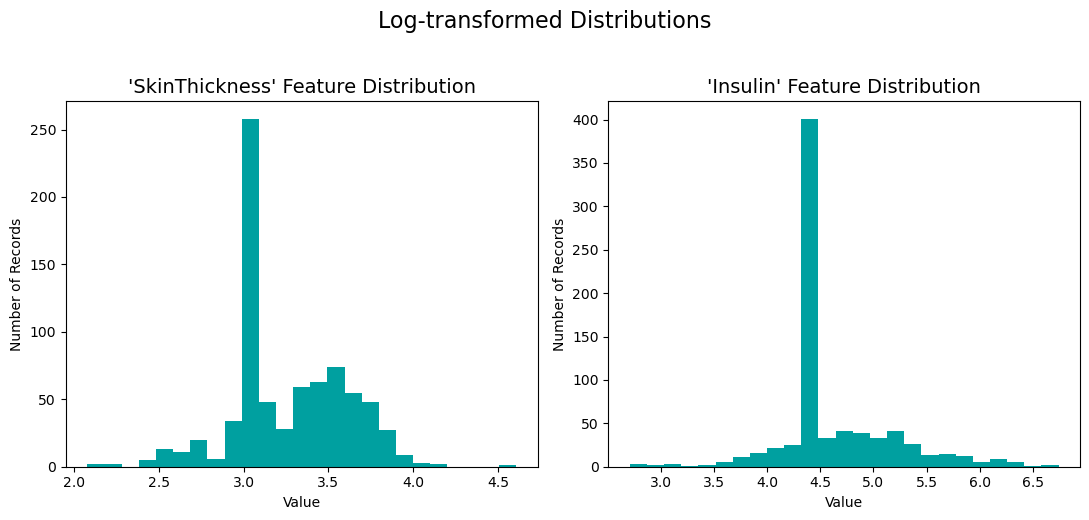

In [8]:
skewed = ["SkinThickness", "Insulin"]
features_log_transformed = pd.DataFrame(data=features)
features_log_transformed[skewed] = features[skewed].apply(lambda x: np.log(x + 1))

plot_distribution(features_log_transformed, "Log-transformed Distributions")

Next we scale the numerical features to a common 0-1 range with `MinMaxScaler`. Models like Logistic Regression are sensitive to feature scale — without this, a feature like `Insulin` (which can be in the hundreds) would dominate a feature like `DiabetesPedigreeFunction` (usually under 2) just because of its raw size, not because it's actually more predictive.

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numerical = ["Insulin", "SkinThickness", "DiabetesPedigreeFunction"]

features_final = pd.DataFrame(data=features_log_transformed)
features_final[numerical] = scaler.fit_transform(features_log_transformed[numerical])

display(features_final.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,0.595502,0.417468,33.6,0.234415,50
1,1,85.0,66.0,0.523317,0.417468,26.6,0.116567,31
2,8,183.0,64.0,0.392087,0.417468,23.3,0.253629,32
3,1,89.0,66.0,0.434968,0.457607,28.1,0.038002,21
4,0,137.0,40.0,0.595502,0.600411,43.1,0.943638,33


## Train / test split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_final, target, test_size=0.2, random_state=42
)

print(f"Training set has {X_train.shape[0]} samples.")
print(f"Testing set has {X_test.shape[0]} samples.")

Training set has 614 samples.
Testing set has 154 samples.


## Choosing models

We'll compare four classifiers, since each makes different assumptions about the data:

1. **Logistic Regression** — a simple, fast linear baseline. Good first model for a binary outcome.
2. **Decision Tree** — captures non-linear splits in the data, easy to interpret.
3. **Random Forest** — an ensemble of decision trees, usually more robust and accurate than a single tree.
4. **Naive Bayes** (Gaussian) — a probabilistic model that assumes features are independent given the class. It's a weak assumption for this dataset (features like Glucose and BMI aren't really independent), but it's cheap to train and a useful comparison point.

### A quick note on the metrics
- **Accuracy**: fraction of predictions that were correct overall.
- **Precision**: of everyone the model predicted as diabetic, what fraction actually were.
- **Recall**: of everyone who actually is diabetic, what fraction the model caught.
- **F-beta score (beta=0.5)**: a weighted blend of precision and recall that leans slightly toward precision — useful here since a false "diabetic" alarm has a real (though smaller) cost too, not just missed cases.

In [11]:
from sklearn.metrics import fbeta_score, accuracy_score

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test):
    """Fit `learner` on the first `sample_size` rows of the training set,
    then report timing, accuracy, and F-score on both a slice of the
    training set and the full test set."""
    results = {}

    start = time()
    learner = learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time()
    results["train_time"] = end - start

    start = time()
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time()
    results["pred_time"] = end - start

    results["acc_train"] = accuracy_score(y_train[:300], predictions_train)
    results["acc_test"] = accuracy_score(y_test, predictions_test)
    results["f_train"] = fbeta_score(y_train[:300], predictions_train, beta=0.5)
    results["f_test"] = fbeta_score(y_test, predictions_test, beta=0.5)

    print(f"{learner.__class__.__name__} trained on {sample_size} samples.")
    return results

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

clf_logreg = LogisticRegression(random_state=42, max_iter=1000)
clf_tree = DecisionTreeClassifier(random_state=42)
clf_forest = RandomForestClassifier(random_state=42)
clf_nb = GaussianNB()

# Train each model on 1%, 10%, and 100% of the training data,
# so we can see how performance scales with data size.
samples_100 = len(y_train)
samples_10 = int(0.1 * samples_100)
samples_1 = int(0.01 * samples_100)

results = {}
for clf in [clf_logreg, clf_tree, clf_forest, clf_nb]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = train_predict(clf, samples, X_train, y_train, X_test, y_test)

LogisticRegression trained on 6 samples.
LogisticRegression trained on 61 samples.
LogisticRegression trained on 614 samples.
DecisionTreeClassifier trained on 6 samples.
DecisionTreeClassifier trained on 61 samples.
DecisionTreeClassifier trained on 614 samples.
RandomForestClassifier trained on 6 samples.
RandomForestClassifier trained on 61 samples.
RandomForestClassifier trained on 614 samples.
GaussianNB trained on 6 samples.
GaussianNB trained on 61 samples.
GaussianNB trained on 614 samples.


## Naive baseline

Before trusting any model, it helps to know how well a "dumb" predictor would do — one that always predicts "diabetic" for everyone. If our trained models can't beat this, they're not actually learning anything useful.

In [13]:
naive_accuracy = n_diabetic / n_records          # correct whenever someone IS diabetic
naive_precision = n_diabetic / n_records          # fraction of "diabetic" guesses that are right
naive_recall = 1.0                                # catches every true diabetic case, since it guesses diabetic for all

beta = 0.5
naive_fscore = (1 + beta**2) * naive_precision * naive_recall / (
    (beta**2 * naive_precision) + naive_recall
)

print(f"Naive Predictor -> Accuracy: {naive_accuracy:.4f}, F-score: {naive_fscore:.4f}")

Naive Predictor -> Accuracy: 0.3490, F-score: 0.4012


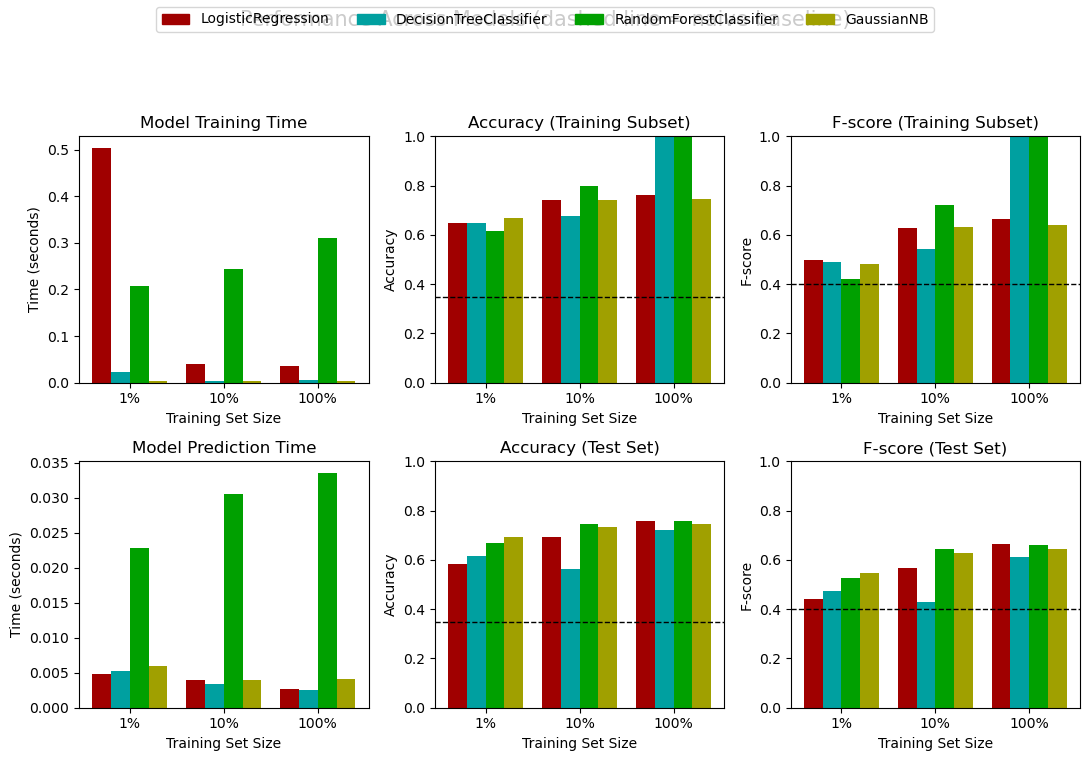

In [14]:
import matplotlib.patches as mpatches

def evaluate(results, accuracy, f1):
    """Bar-chart comparison of accuracy/F-score/timing across models and training sizes."""
    fig, ax = plt.subplots(2, 3, figsize=(11, 7))
    bar_width = 0.2
    colors = ["#A00000", "#00A0A0", "#00A000", "#A0A000"]

    for k, learner in enumerate(results.keys()):
        for j, metric in enumerate(["train_time", "acc_train", "f_train", "pred_time", "acc_test", "f_test"]):
            for i in np.arange(3):
                ax[j // 3, j % 3].bar(i + k * bar_width, results[learner][i][metric], width=bar_width, color=colors[k])
                ax[j // 3, j % 3].set_xticks([0.3, 1.3, 2.3])
                ax[j // 3, j % 3].set_xticklabels(["1%", "10%", "100%"])
                ax[j // 3, j % 3].set_xlabel("Training Set Size")

    ax[0, 0].set_ylabel("Time (seconds)")
    ax[0, 1].set_ylabel("Accuracy")
    ax[0, 2].set_ylabel("F-score")
    ax[1, 0].set_ylabel("Time (seconds)")
    ax[1, 1].set_ylabel("Accuracy")
    ax[1, 2].set_ylabel("F-score")

    ax[0, 0].set_title("Model Training Time")
    ax[0, 1].set_title("Accuracy (Training Subset)")
    ax[0, 2].set_title("F-score (Training Subset)")
    ax[1, 0].set_title("Model Prediction Time")
    ax[1, 1].set_title("Accuracy (Test Set)")
    ax[1, 2].set_title("F-score (Test Set)")

    for row, col in [(0, 1), (1, 1)]:
        ax[row, col].axhline(y=accuracy, linewidth=1, color="k", linestyle="dashed")
        ax[row, col].set_ylim((0, 1))
    for row, col in [(0, 2), (1, 2)]:
        ax[row, col].axhline(y=f1, linewidth=1, color="k", linestyle="dashed")
        ax[row, col].set_ylim((0, 1))

    patches = [mpatches.Patch(color=colors[i], label=learner) for i, learner in enumerate(results.keys())]
    fig.legend(handles=patches, loc="upper center", ncol=4, fontsize="medium")
    plt.suptitle("Performance Across Models (dashed line = naive baseline)", fontsize=15, y=1.08)
    plt.tight_layout()
    plt.show()

evaluate(results, naive_accuracy, naive_fscore)

## A closer look at Random Forest

Accuracy and F-score are useful summaries, but a confusion matrix shows exactly where the model is going wrong — specifically, how many diabetic patients it's missing (false negatives), which matters a lot in a medical context.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

forest_preds = clf_forest.predict(X_test)
print(confusion_matrix(y_test, forest_preds))
print(classification_report(y_test, forest_preds))

[[79 20]
 [17 38]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        99
           1       0.66      0.69      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



## Tuning the model

Random Forest performed well above, so we tune its hyperparameters with grid search to squeeze out more performance. We search over the number of trees (`n_estimators`) and tree depth (`max_depth`), using 5-fold cross-validation and scoring by F-beta (beta=0.5) so the search optimizes for the same metric we actually care about.

In [16]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

clf = RandomForestClassifier(random_state=42)
parameters = {"n_estimators": [5, 10, 15, 20, 25], "max_depth": [2, 4, 6, 8, 10]}
scorer = make_scorer(fbeta_score, beta=0.5)

grid_obj = GridSearchCV(clf, parameters, scoring=scorer, cv=5)
grid_fit = grid_obj.fit(X_train, y_train)
best_clf = grid_fit.best_estimator_

predictions = clf.fit(X_train, y_train).predict(X_test)
best_predictions = best_clf.predict(X_test)

print("Random Forest")
print(f"Unoptimized accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Optimized accuracy:   {accuracy_score(y_test, best_predictions):.4f}")
print(f"Unoptimized F-score:  {fbeta_score(y_test, predictions, beta=0.5):.4f}")
print(f"Optimized F-score:    {fbeta_score(y_test, best_predictions, beta=0.5):.4f}")
print(f"Best parameters: {grid_fit.best_params_}")

Random Forest
Unoptimized accuracy: 0.7597
Optimized accuracy:   0.7662
Unoptimized F-score:  0.6620
Optimized F-score:    0.6742
Best parameters: {'max_depth': 10, 'n_estimators': 25}


## Feature importance

Which health measurements actually drive the prediction? Random Forest gives us this for free via `feature_importances_`.

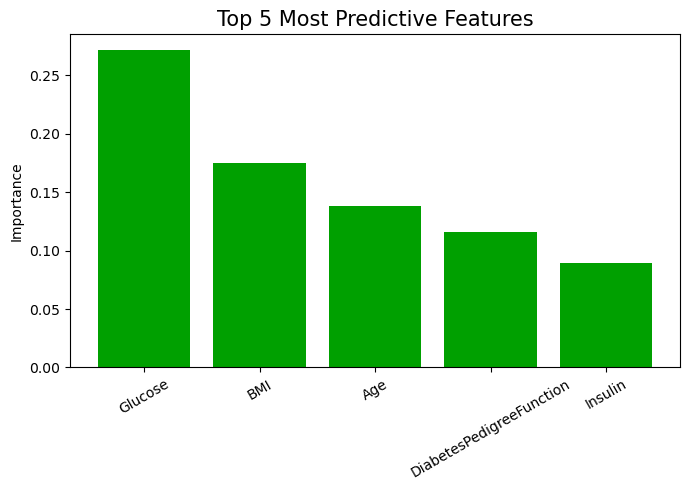

In [17]:
def feature_plot(importances, X_train):
    indices = np.argsort(importances)[::-1]
    columns = X_train.columns.values[indices[:5]]
    values = importances[indices][:5]

    plt.figure(figsize=(7, 5))
    plt.title("Top 5 Most Predictive Features", fontsize=15)
    plt.bar(np.arange(5), values, color="#00A000")
    plt.xticks(np.arange(5), columns, rotation=30)
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()

importances = best_clf.feature_importances_
feature_plot(importances, X_train)

## Does using fewer features hurt performance?

Training on only the top 3 features cuts dimensionality, which can speed up training and reduce overfitting risk — but it can also throw away useful signal. Let's check the trade-off directly.

In [18]:
from sklearn.base import clone

top_3_idx = np.argsort(importances)[::-1][:3]
top_3_cols = X_train.columns.values[top_3_idx]
print("Top 3 features:", list(top_3_cols))

X_train_reduced = X_train[top_3_cols]
X_test_reduced = X_test[top_3_cols]

clf_reduced = clone(best_clf).fit(X_train_reduced, y_train)
reduced_predictions = clf_reduced.predict(X_test_reduced)

print("Final model -- full feature set")
print(f"Accuracy: {accuracy_score(y_test, best_predictions):.4f}, F-score: {fbeta_score(y_test, best_predictions, beta=0.5):.4f}")
print("\nFinal model -- top-3 features only")
print(f"Accuracy: {accuracy_score(y_test, reduced_predictions):.4f}, F-score: {fbeta_score(y_test, reduced_predictions, beta=0.5):.4f}")

Top 3 features: ['Glucose', 'BMI', 'Age']
Final model -- full feature set
Accuracy: 0.7662, F-score: 0.6742

Final model -- top-3 features only
Accuracy: 0.7403, F-score: 0.6355


## Saving the model

We save the tuned Random Forest and the fitted `MinMaxScaler` to disk with `joblib`, so the Streamlit app (`app.py` in this project) can load them and make predictions on new patient data without retraining.

In [19]:
import joblib

joblib.dump(best_clf, "diabetes_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved diabetes_model.joblib and scaler.joblib")

Saved diabetes_model.joblib and scaler.joblib


## Conclusion

The tuned Random Forest beat the naive baseline on F-score while staying close on accuracy, and blood-sugar-related features (Insulin, Glucose) tend to rank high in feature importance, in line with the clinical intuition that blood sugar regulation markers are the strongest signals for diabetes risk.

**Possible next steps:** try `class_weight='balanced'` or SMOTE to address the class imbalance more directly, or try XGBoost as a stronger ensemble baseline.